In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from aux import format_plot
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from time import time

plt.rcParams['font.family'] = 'Helvetica'

In [4]:
def calc_alpha_func(tau_alpha):
	alpha_func_n_steps = int(10 * tau_alpha / dt)
	t_alpha = np.arange(0, alpha_func_n_steps) * dt
	return np.e * t_alpha / tau_alpha * np.exp(-t_alpha/tau_alpha)

def poisson_arrivals_to_inputs(arrivals, tau_alpha):
	alpha_func = calc_alpha_func(tau_alpha)
	input_current = np.zeros(arrivals.shape)

	for i in range(arrivals.shape[1]):
		input_current[:, i] = np.convolve(alpha_func, arrivals[:, i], mode='full')[:arrivals.shape[0]]
	return input_current

In [5]:
BATCH_SIZE = 10
T = 0.3
T_INPUT = 0.27
INPUT_RATE_PER_CELL = 1000
dt = 1e-4 # Timesteps
INPUT_BLOCK_DURATION = 10e-3
input_block_timesteps = int(INPUT_BLOCK_DURATION / dt)
input_start = int(20e-3/dt)
input_end = input_start + int(T_INPUT/dt)
max_input_len = input_end - input_start
decoder_lag = int(5e-3/dt)
decoding_len = int(T / dt - decoder_lag - input_start)
n_e_side = 10

def gen_input_1(index):
    input_rate_for_trial = 2 * INPUT_RATE_PER_CELL * (0.25 + 0.75 * index / (BATCH_SIZE - 1))
    
    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))
    n_input_blocks = max_input_len // input_block_timesteps
    inputs = np.random.choice([-1, 0, 1], size=n_input_blocks).astype(int)
    
    for i_input_block, input_flag in enumerate(inputs):
        k = i_input_block * input_block_timesteps
        if input_flag == -1:
            input_block = np.repeat(np.random.poisson(lam=input_rate_for_trial * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
        elif input_flag == 1:
            input_block = np.repeat(np.random.poisson(lam=input_rate_for_trial * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = input_block
    return poisson_arrivals_to_inputs(input_spks, 3e-3)

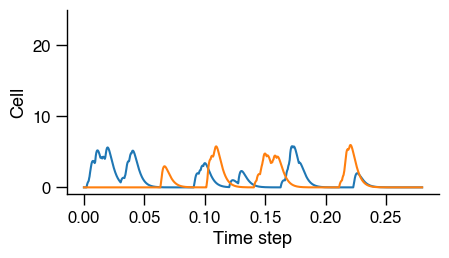

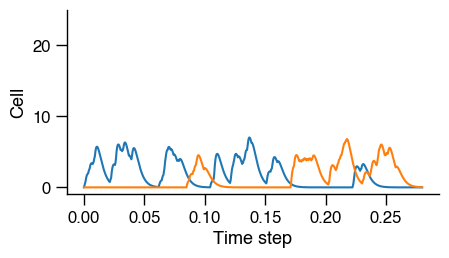

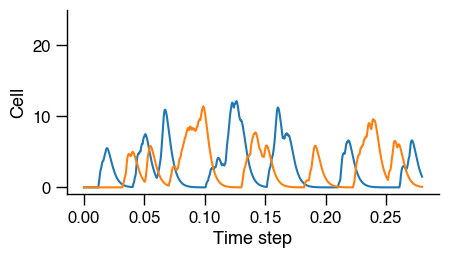

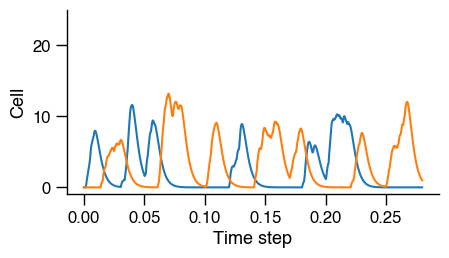

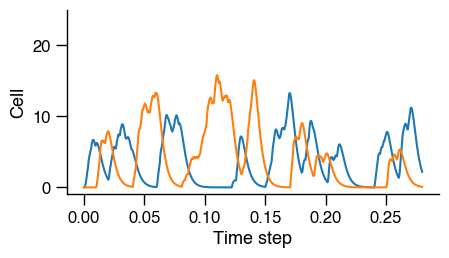

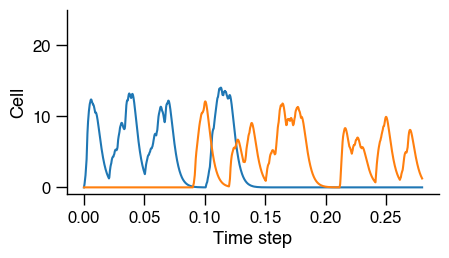

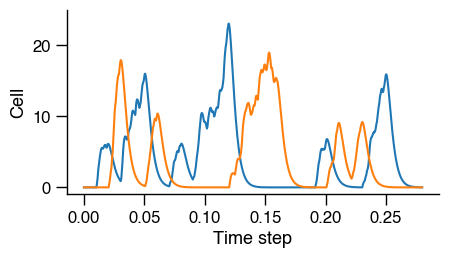

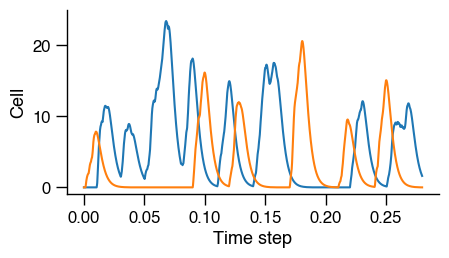

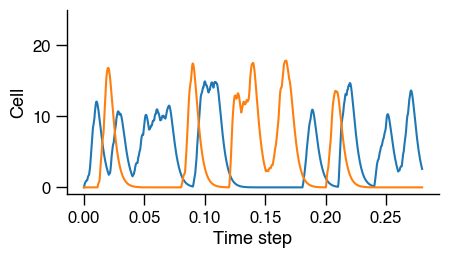

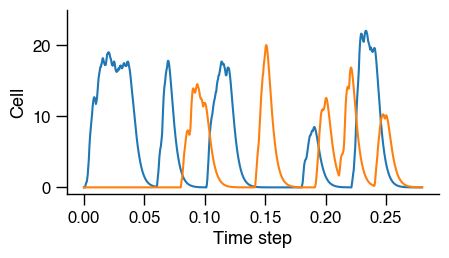

In [6]:
for i in range(10):
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(8 * scale, 4 * scale))
    
    inputs = gen_input_1(i)
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 0])
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 10])

    axes.set_ylim(-1, 25)

    axes.set_xlabel('Time step')
    axes.set_ylabel('Cell')

    format_plot(axes)

In [14]:
def gen_input_2(index):
    input_len = int((index + 1) / (BATCH_SIZE + 1) * max_input_len)
    
    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))
		
    n_input_blocks = input_len // input_block_timesteps
    inputs = np.zeros((n_input_blocks), dtype=int)
    n_inputs = np.random.randint(0, n_input_blocks + 1)
    if n_inputs > 0:
        inputs[:n_inputs] = np.random.choice([-1, 1], size=n_inputs)
    np.random.shuffle(inputs)

    for i_input_block, input_flag in enumerate(inputs):
        k = i_input_block * input_block_timesteps
        if input_flag == -1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
        elif input_flag == 1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = input_block

    inputs = poisson_arrivals_to_inputs(input_spks, 3e-3)

    filtered_input_to_sum = inputs[:, n_e_side:2 * n_e_side].sum(axis=1) - inputs[:, :n_e_side].sum(axis=1)
    running_input_sums = np.zeros_like(filtered_input_to_sum)
    for j in range(len(running_input_sums)):
        if j > 0:
            running_input_sums[j] += running_input_sums[j-1]
        running_input_sums[j] += filtered_input_to_sum[j]
    return inputs, running_input_sums

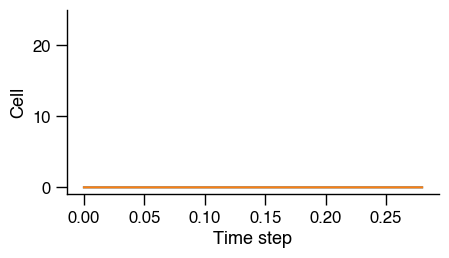

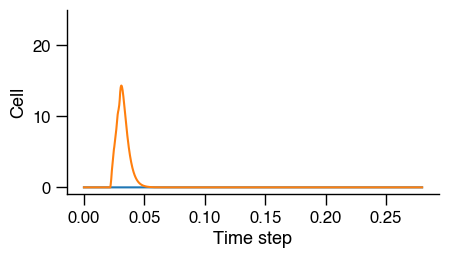

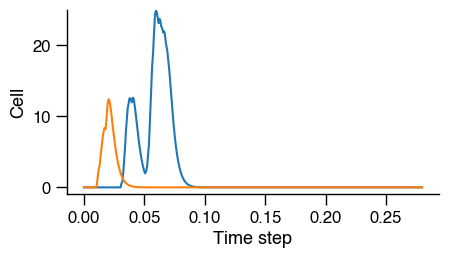

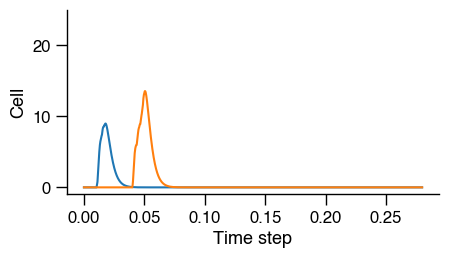

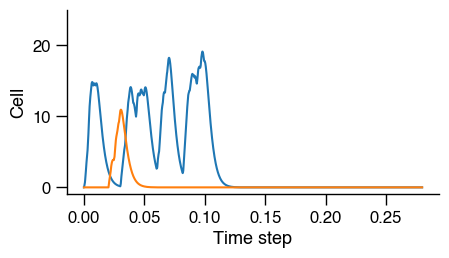

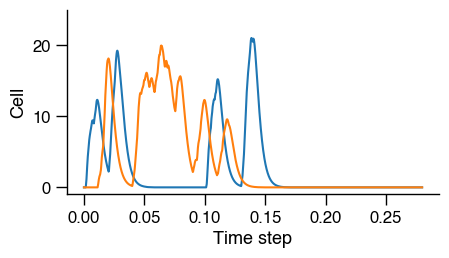

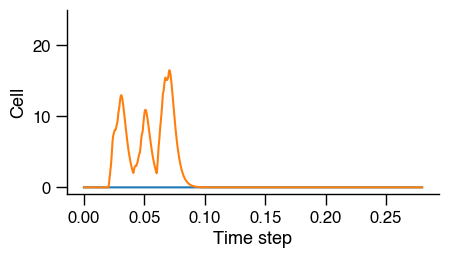

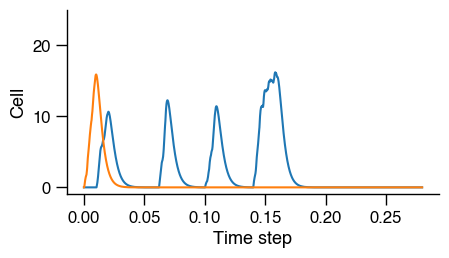

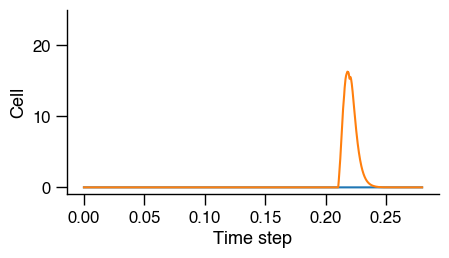

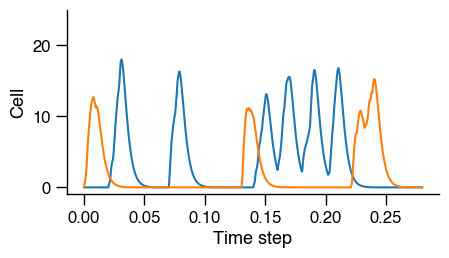

In [25]:
INPUT_BLOCK_DURATION = 10e-3
input_block_timesteps = int(INPUT_BLOCK_DURATION / dt)

for i in range(10):
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(8 * scale, 4 * scale))
    
    inputs, totals = gen_input_2(i)
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 0])
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 10])
    axes.set_ylim(-1, 25)
    
    axes.set_xlabel('Time step')
    axes.set_ylabel('Cell')

    format_plot(axes)

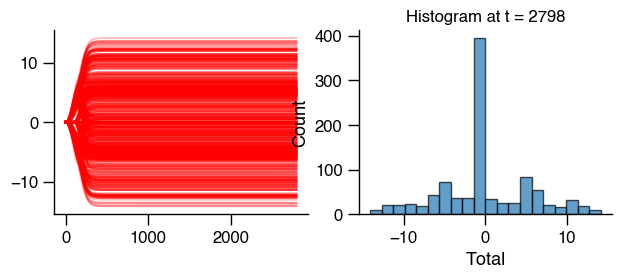

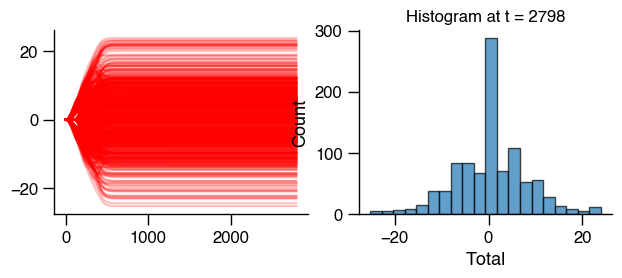

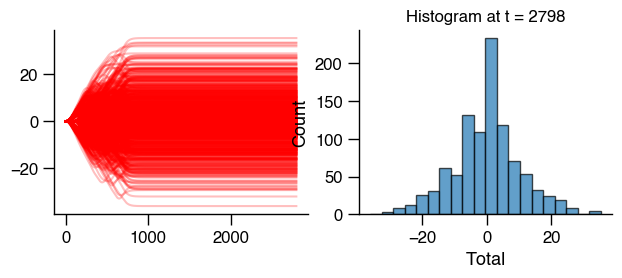

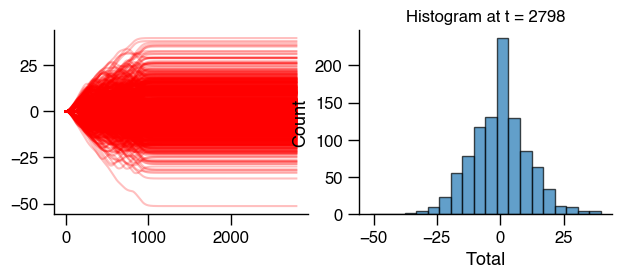

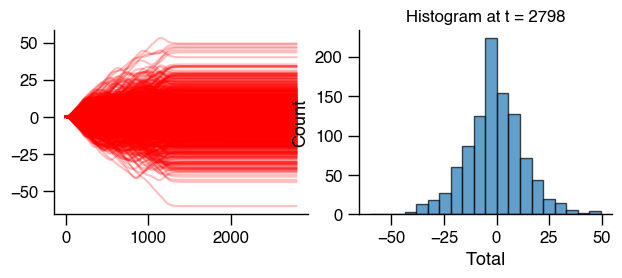

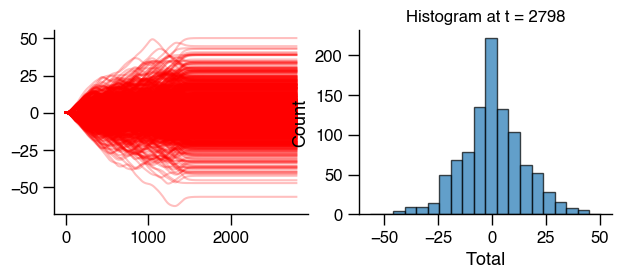

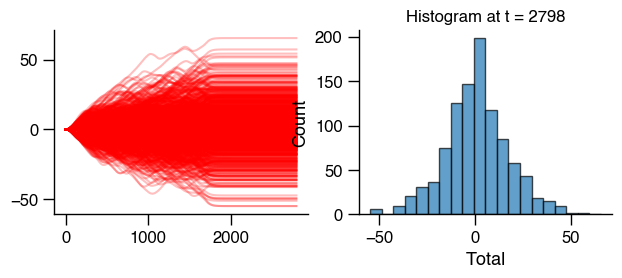

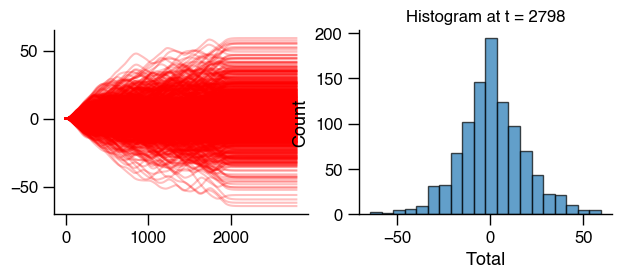

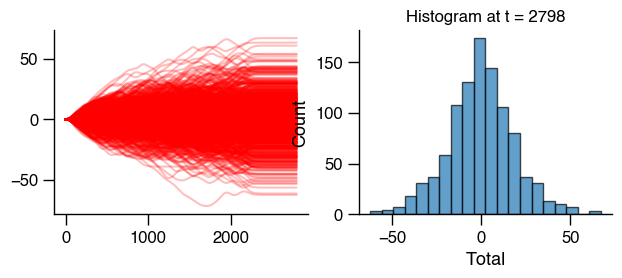

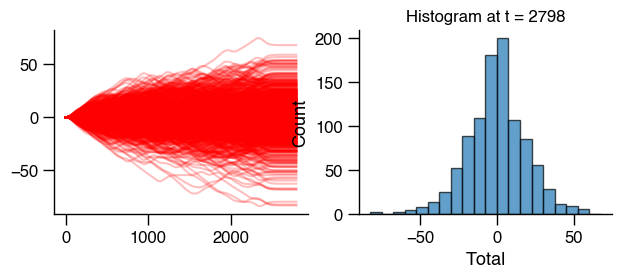

In [60]:
for index in range(10):
    fig, axes = plt.subplots(1, 2, figsize=(12 * scale, 4 * scale))
    
    # Left panel: traces
    trace_ax = axes[0]
    # Right panel: histogram
    hist_ax = axes[1]
    
    all_totals_at_t = []
    t_idx = 2798  # <-- choose the timestep you want
    
    for i in range(1000):
        inputs, totals = gen_input_2(index)
        totals /= (0.3 / dt)
    
        # store the value at time t_idx
        if t_idx < len(totals):
            all_totals_at_t.append(totals[t_idx])
    
        trace_ax.plot(np.arange(len(totals)), totals, alpha=0.25, color='red')
    
    format_plot(trace_ax)
    
    # Histogram of values at timestep t_idx
    hist_ax.hist(all_totals_at_t, bins=20, edgecolor='black', alpha=0.7)
    hist_ax.set_title(f"Histogram at t = {t_idx}")
    hist_ax.set_xlabel("Total")
    hist_ax.set_ylabel("Count")
    format_plot(hist_ax)

In [30]:
def gen_input_3(index):
    input_len = max_input_len
    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))
    n_input_blocks = input_len // input_block_timesteps

    p_active = 0.25 + 0.75 * index / BATCH_SIZE
    inputs = np.random.choice([0, -1, 1], size=n_input_blocks, p=[1-p_active, p_active/2, p_active/2])

    for i_input_block, input_flag in enumerate(inputs):
        k = i_input_block * input_block_timesteps
        if input_flag == -1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
        elif input_flag == 1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = input_block

    inputs = poisson_arrivals_to_inputs(input_spks, 3e-3)

    filtered_input_to_sum = inputs[:, n_e_side:2 * n_e_side].sum(axis=1) - inputs[:, :n_e_side].sum(axis=1)
    running_input_sums = np.zeros_like(filtered_input_to_sum)
    for j in range(len(running_input_sums)):
        if j > 0:
            running_input_sums[j] += running_input_sums[j-1]
        running_input_sums[j] += filtered_input_to_sum[j]
    return inputs, running_input_sums

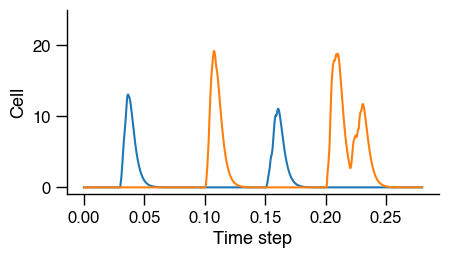

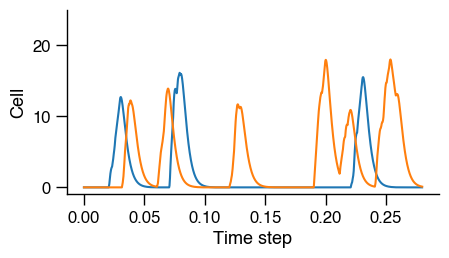

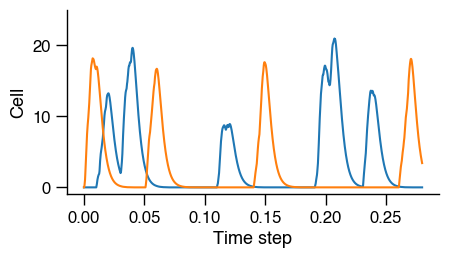

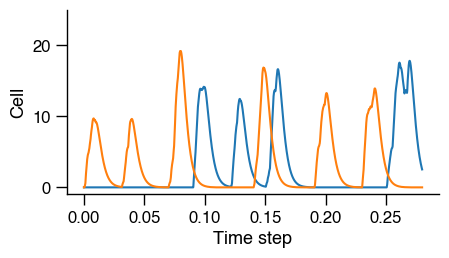

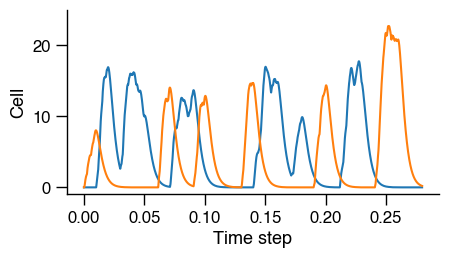

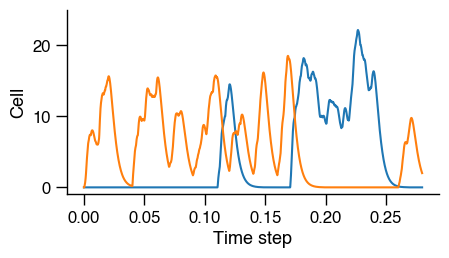

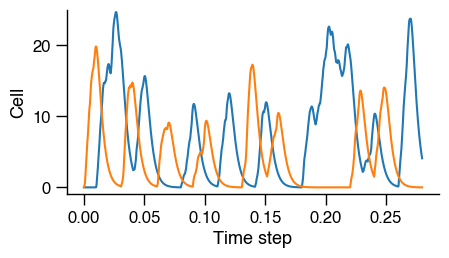

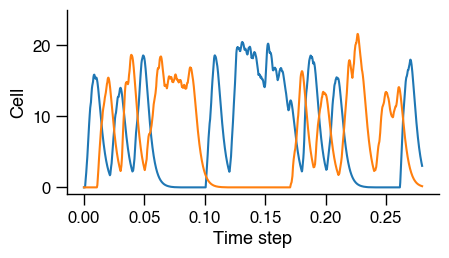

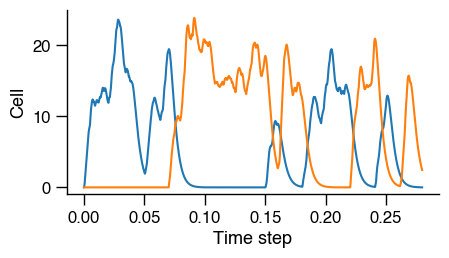

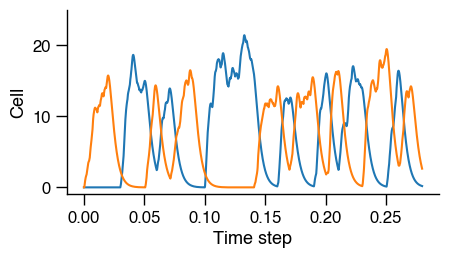

In [31]:
for i in range(10):
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(8 * scale, 4 * scale))
    
    inputs, totals = gen_input_3(i)
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 0])
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 10])
    axes.set_ylim(-1, 25)
    
    axes.set_xlabel('Time step')
    axes.set_ylabel('Cell')

    format_plot(axes)

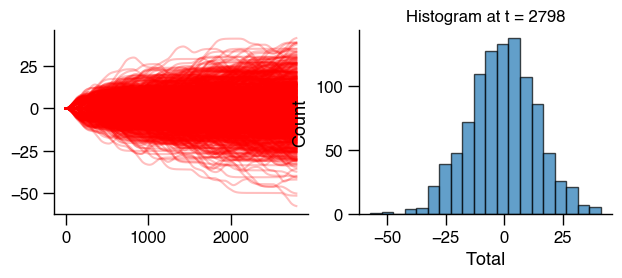

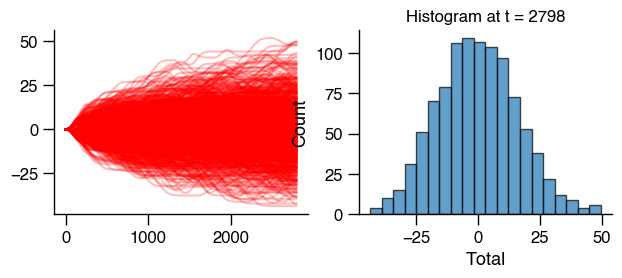

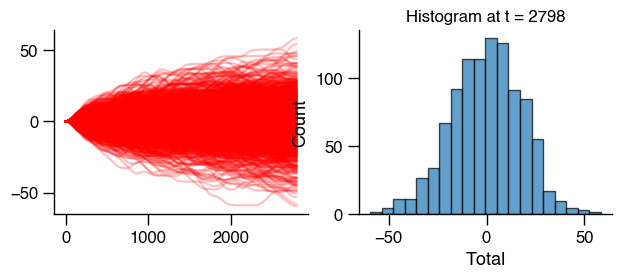

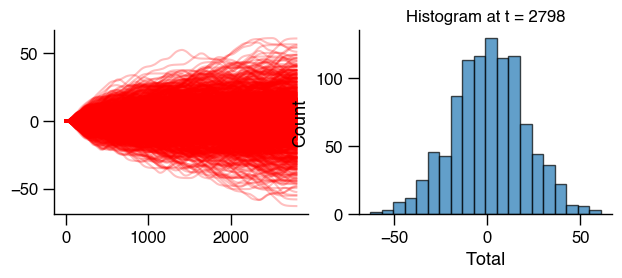

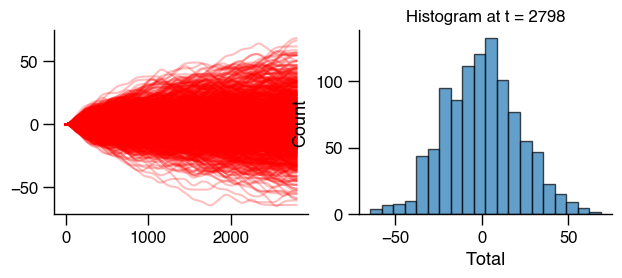

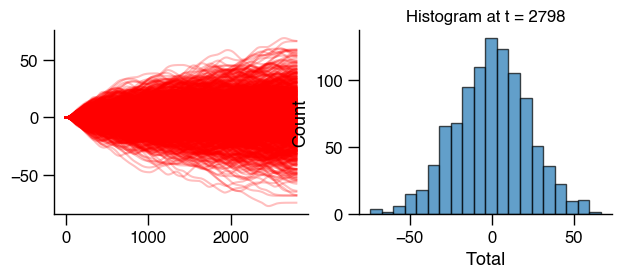

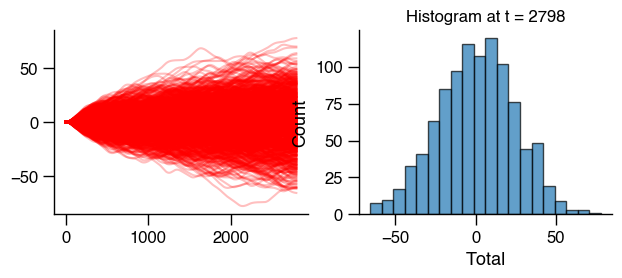

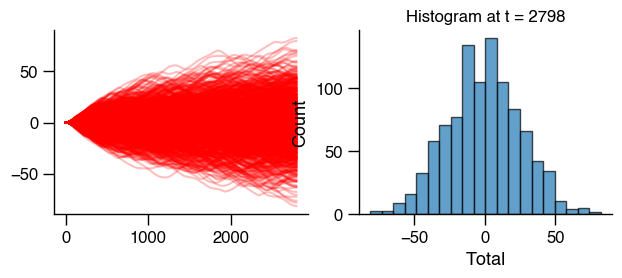

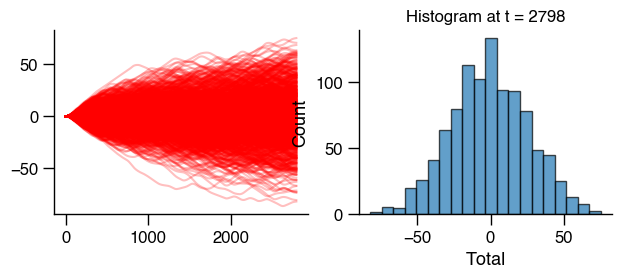

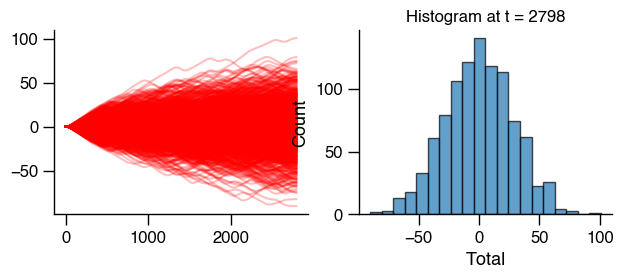

In [61]:
for index in range(10):
    fig, axes = plt.subplots(1, 2, figsize=(12 * scale, 4 * scale))
    
    # Left panel: traces
    trace_ax = axes[0]
    # Right panel: histogram
    hist_ax = axes[1]
    
    all_totals_at_t = []
    t_idx = 2798  # <-- choose the timestep you want
    
    for i in range(1000):
        inputs, totals = gen_input_3(index)
        totals /= (0.3 / dt)
    
        # store the value at time t_idx
        if t_idx < len(totals):
            all_totals_at_t.append(totals[t_idx])
    
        trace_ax.plot(np.arange(len(totals)), totals, alpha=0.25, color='red')
    
    format_plot(trace_ax)
    
    # Histogram of values at timestep t_idx
    hist_ax.hist(all_totals_at_t, bins=20, edgecolor='black', alpha=0.7)
    hist_ax.set_title(f"Histogram at t = {t_idx}")
    hist_ax.set_xlabel("Total")
    hist_ax.set_ylabel("Count")
    format_plot(hist_ax)